# **Phân tích lỗi mô hình dịch: Tiếng Miền Tây -> Phổ Thông**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Thiết lập font chữ và style cho biểu đồ
plt.style.use('ggplot')
sns.set_palette("pastel")

## **1. Tải dữ liệu và lấy mẫu ngẫu nhiên**


Do file dịch sai có tới 2400 dòng nên chỉ lấy ra ngẫu nhiên 100 câu bị dịch sai để phân tích lỗi.

In [2]:
df = pd.read_csv('cac_cau_dich_sai.csv')
print(f"Tổng số câu lỗi ban đầu: {len(df)}")

# Lấy ngẫu nhiên 100 sample để phân tích sâu
df_sample = df.sample(n=100, random_state=42).copy()
print(f"Số lượng câu sau khi lấy mẫu: {len(df_sample)}")
df_sample.head()

Tổng số câu lỗi ban đầu: 2454
Số lượng câu sau khi lấy mẫu: 100


,Câu gốc (Input),Đúng chuẩn (Reference),LoRA Dịch (Prediction)
2116,"Gió quạt nhẹ hều vậy, ngồi cũng nóng hầm hập à.",Luồng gió quá yếu nên vẫn cảm thấy nóng bức.,"Gió thổi nhẹ nhàng thế này, ngồi cũng nóng hầm..."
700,"Bữa nay tui thấy người nó lừ đừ, chắc tại thời...","Hôm nay tôi thấy người lờ đờ, chắc tại thời ti...","Hôm nay tôi thấy người nó lừ đừ, chắc tại thời..."
1165,"Nghe nói bên đó có bùa chú, ai cũng đồn hết trơn.",Nghe kể rằng họ sở hữu bùa chú khá linh nghiệm.,"Nghe nói bên đó có bùa chú, ai cũng đồn hết cả."
2418,Thất tình hay sao mà buồn nhau nháu vậy ông bạn.,Thất tình hay sao mà buồn rười rượi vậy ông bạn.,Thất tình hay sao mà buồn nhau nhõng nhẽo thế ...
1627,"Ngày nào cũng lo ăn cho bấy nhiêu người, chạy ...","Ngày nào cũng lo ăn cho bấy nhiêu người, chạy ...","Ngày nào cũng lo ăn cho bao nhiêu người, chạy ..."


## **2. Trực quan hóa bằng WordCloud**
Gộp tất cả các câu tiếng Miền Tây (hoặc các câu dịch lỗi) để xem từ vựng nào xuất hiện nhiều nhất.

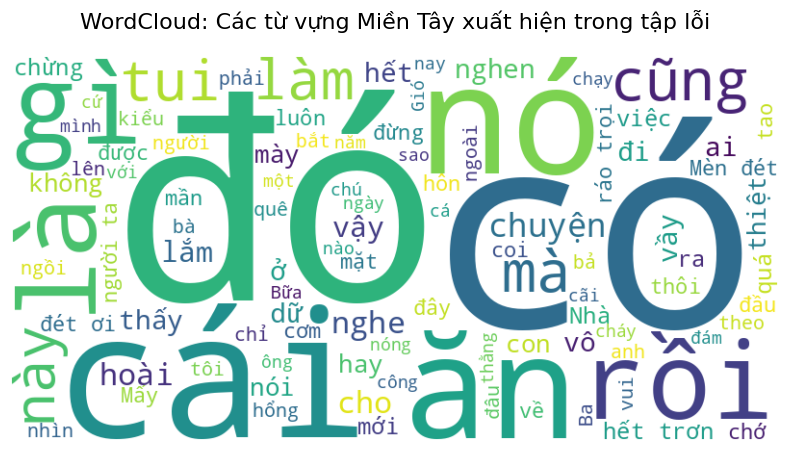

In [11]:
# Lấy text từ cột source (Tiếng Miền Tây gốc)
text_corpus = " ".join(df_sample['Câu gốc (Input)'].astype(str).tolist())

# Tạo WordCloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(text_corpus)

# Hiển thị biểu đồ
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud: Các từ vựng Miền Tây xuất hiện trong tập lỗi', fontsize=16, pad=20)
plt.savefig('wordcloud.png')
plt.show()

## **3. Phân loại lỗi và Biểu đồ cột**
Các loại lỗi thường gặp trong dịch máy:
- **Polysemy**: Lỗi đa nghĩa (Một từ có nhiều nghĩa nhưng mô hình chọn sai ngữ cảnh).
- **OOV (Out of Vocabulary)**: Từ vựng chưa từng xuất hiện, mô hình không biết dịch.
- **Literal Translation**: Dịch word-by-word (dịch sát nghĩa đen, thiếu tự nhiên).
- **Hallucination**: Sinh ảo (Mô hình tự bịa ra từ hoặc ý không có trong câu gốc).

/tmp/ipykernel_839/947259611.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Số Lượng', y='Loại Lỗi', data=error_counts, palette='Set2')


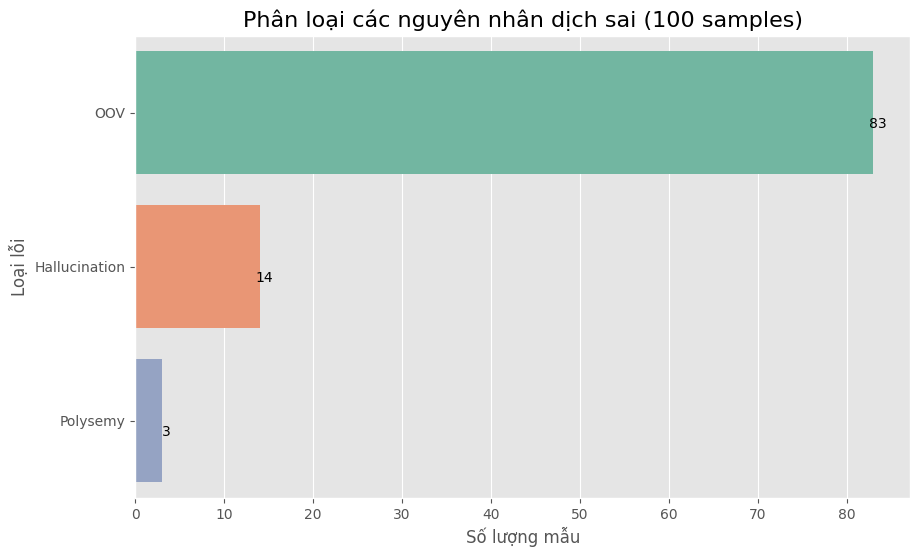

In [9]:
# error_categories = ['Polysemy', 'OOV', 'Literal Translation', 'Hallucination', 'Grammar/Syntax']
df_sample = pd.read_csv('phan_loai_loi_dich_lora.csv')

# Thống kê số lượng
error_counts = df_sample['error_type'].value_counts().reset_index()
error_counts.columns = ['Loại Lỗi', 'Số Lượng']

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Số Lượng', y='Loại Lỗi', data=error_counts, palette='Set2')

# Gắn số lượng lên từng cột
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.5, p.get_y() + p.get_height()/2. + 0.1, '{:1.0f}'.format(width), ha="center")

plt.title('Phân loại các nguyên nhân dịch sai (100 samples)', fontsize=16)
plt.xlabel('Số lượng mẫu', fontsize=12)
plt.ylabel('Loại lỗi', fontsize=12)
plt.show()

## **4. Trực quan hóa 15 Cases dịch sai tiêu biểu**
Chúng ta sẽ in ra dạng bảng để dễ dàng quan sát câu gốc, câu dịch của mô hình, câu tham chiếu và loại lỗi.

In [10]:
# Lấy ra 15 trường hợp để review
review_cases = df_sample[['Câu gốc (Input)', 'Đúng chuẩn (Reference)', 'LoRA Dịch (Prediction)', 'error_type']].head(15)

# Tuỳ chỉnh Pandas hiển thị cho đẹp
pd.set_option('display.max_colwidth', None)

# Hiển thị bảng
display(review_cases.style.set_properties(**{
    'text-align': 'left',
    'background-color': '#f9f9f9',
    'border': '1px solid black'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('font-size', '14px')]}
]))

,Câu gốc (Input),Đúng chuẩn (Reference),LoRA Dịch (Prediction),error_type
0,"Gió quạt nhẹ hều vậy, ngồi cũng nóng hầm hập à.",Luồng gió quá yếu nên vẫn cảm thấy nóng bức.,"Gió thổi nhẹ nhàng thế này, ngồi cũng nóng hầm hập à.",OOV
1,"Bữa nay tui thấy người nó lừ đừ, chắc tại thời tiết đổi mùa.","Hôm nay tôi thấy người lờ đờ, chắc tại thời tiết đổi mùa.","Hôm nay tôi thấy người nó lừ đừ, chắc tại thời tiết đổi mùa.",OOV
2,"Nghe nói bên đó có bùa chú, ai cũng đồn hết trơn.",Nghe kể rằng họ sở hữu bùa chú khá linh nghiệm.,"Nghe nói bên đó có bùa chú, ai cũng đồn hết cả.",OOV
3,Thất tình hay sao mà buồn nhau nháu vậy ông bạn.,Thất tình hay sao mà buồn rười rượi vậy ông bạn.,Thất tình hay sao mà buồn nhau nhõng nhẽo thế anh bạn.,OOV
4,"Ngày nào cũng lo ăn cho bấy nhiêu người, chạy vầy là khẳm thiệt chớ.","Ngày nào cũng lo ăn cho bấy nhiêu người, chạy thế này là bở hơi tai thật đấy.","Ngày nào cũng lo ăn cho bao nhiêu người, chạy thế này là mệt thật chứ.",Hallucination
5,Con mèo cứ lui hửi quanh cái tủ chén hoài.,Con mèo cứ sục sạo ngửi quanh cái tủ chén suốt.,Con mèo cứ lượn lờ quanh cái tủ chén mãi.,Hallucination
6,"Gió lao rao vầy làm tàu cau nhỏng nhánh, tui ngồi đây hoài hổng chán.","Gió xào xạc thế này làm tàu cau lúng liếng, tôi ngồi đây mãi không chán.","Gió lao xao thế này làm tàu cau nhỏng nhánh, tôi ngồi đây mãi không chán.",OOV
7,Nhà bữa nay đám tiệc gì mà giàn giá dữ vậy anh Tư?,Nhà có tiệc gì mà bày biện linh đình thế này,Nhà hôm nay có đám tiệc gì mà hoành tráng thế anh Tư?,OOV
8,"Coi chừng ma da rủ giò vầy đó, ông cẩn thận nghe.","Coi chừng ma nước kéo chân thế này đấy, anh cẩn thận nhé.","Coi chừng ma da rủ giò thế này đấy, anh cẩn thận nghe.",OOV
9,Cá chạch lấu đem kho nghệ ăn hao cơm dữ lắm nghen con.,Cá chạch lấu mang kho nghệ ăn tốn cơm nhiều lắm nhé con.,Cá chạch lấu đem kho nghệ ăn hao cơm lắm đấy nhé con.,OOV
